# Validation Results Inspection

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import sys
import os

sys.path.append("..")

os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [20]:
import numpy as np
import matplotlib.pyplot as plt

import re
from collections import defaultdict

from gyaradax.plot_utils import (
    plot_flux_trace,
    plot_spectra,
    plot_growth_rates,
    plot_growth_snapshots,
)
from gyaradax.params import load_config
from gyaradax.utils import load_geometry

In [24]:
adiabatic_dirs = sorted([d for d in os.listdir("../zmp") if d.startswith("validation_outputs_")])
kinetic_dirs = sorted([d for d in os.listdir("..") if d.startswith("validation_kinetic_")])
print(f"adiabatic: {adiabatic_dirs}")
print(f"kinetic: {kinetic_dirs}")


adiabatic: ['validation_outputs_iteration_13a', 'validation_outputs_iteration_13b', 'validation_outputs_iteration_13c']
kinetic: ['validation_kinetic_v3_kiteration_991_half_rlt']


## 1. Adiabatic Flux Comparison

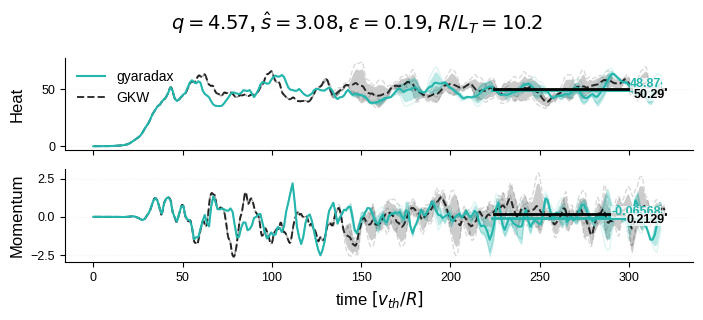

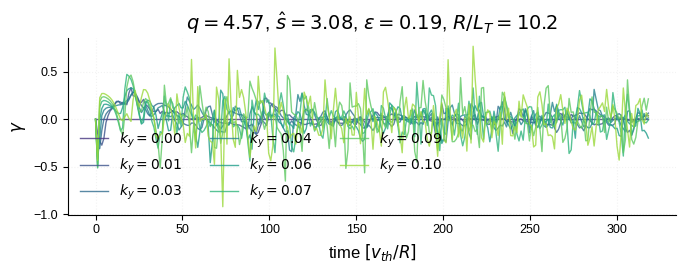

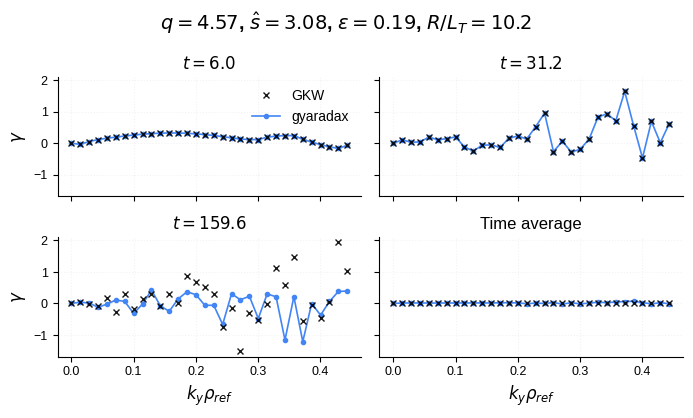

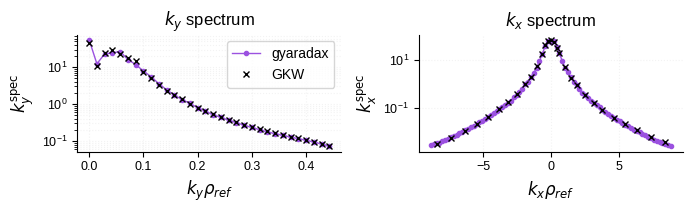

In [25]:
os.makedirs("figs", exist_ok=True)

grouped_adiabatic = defaultdict(list)
for out_dir in adiabatic_dirs:
    config_name = out_dir.replace("validation_outputs_", "")
    base_name = re.sub(r"[a-z]$", "", config_name)
    grouped_adiabatic[base_name].append(out_dir)
    
for base_name, dirs in grouped_adiabatic.items():
    all_fluxes, all_growths, all_times = [], [], []
    all_kx_specs, all_ky_specs = [], []
    
    for out_dir in dirs:
        path = os.path.join("..", out_dir)
        flux_path = os.path.join(path, "fluxes.npz")
        growth_path = os.path.join(path, "growth.npz")
        
        if not os.path.exists(flux_path) or not os.path.exists(growth_path):
            continue

        all_fluxes.append(np.load(flux_path)["fluxes"])
        gdata = np.load(growth_path)
        all_times.append(gdata["time"])
        all_growths.append(gdata["growth"])

        kx_spec_path = os.path.join(path, "kxspec.npz")
        ky_spec_path = os.path.join(path, "kyspec.npz")
        if os.path.exists(kx_spec_path) and os.path.exists(ky_spec_path):
            all_kx_specs.append(np.load(kx_spec_path)["kx_spec"])
            all_ky_specs.append(np.load(ky_spec_path)["ky_spec"])

    if not all_fluxes:
        continue
    
    min_len = min(len(t) for t in all_times)
    sim_time = all_times[0][:min_len]
    sim_flux = np.stack([f[:min_len].T for f in all_fluxes])
    sim_growth = np.stack([g[:min_len] for g in all_growths])
    sim_growth_mean = np.mean(sim_growth, axis=0)

    ref_time, ref_fluxes, ref_fluxes_plot = None, None, None
    kx, ky = None, None
    title = base_name
    ref_dir = None
    
    all_ref_times = []
    all_ref_fluxes = []
    
    for out_dir in dirs:
        config_name = out_dir.replace("validation_outputs_", "")
        c_path = os.path.join("..", "configs", f"{config_name}.yaml")
        if os.path.exists(c_path):
            cfg = load_config(c_path)
            rdir = cfg.run.data_dir
            if ref_dir is None:
                ref_dir = rdir
                
            if os.path.exists(os.path.join(rdir, "time.dat")) and os.path.exists(os.path.join(rdir, "fluxes.dat")):
                all_ref_times.append(np.loadtxt(os.path.join(rdir, "time.dat")))
                all_ref_fluxes.append(np.loadtxt(os.path.join(rdir, "fluxes.dat")).T)

    if all_ref_times:
        ref_min_len = min(len(t) for t in all_ref_times)
        ref_time = all_ref_times[0][:ref_min_len]
        if len(all_ref_fluxes) > 1:
            ref_fluxes = np.stack([f[:, :ref_min_len] for f in all_ref_fluxes])
            ref_fluxes_plot = ref_fluxes[:, [1, 2], :]
        else:
            ref_fluxes = all_ref_fluxes[0][:, :ref_min_len]
            ref_fluxes_plot = ref_fluxes[[1, 2], :]

    if ref_dir:
        geom = load_geometry(ref_dir)
        kx = np.asarray(geom["kxrh"])
        ky = np.asarray(geom["krho"])

        q = float(geom["q"])
        shat = float(geom["shat"])
        eps = float(geom["eps"])
        rlt = float(np.asarray(geom["rlt"]).flat[0])
        title = (
            rf"$q={q:.2f}$, $\hat{{s}}={shat:.2f}$, " rf"$\varepsilon={eps:.2f}$, $R/L_T={rlt:.1f}$"
        )

    fig = plot_flux_trace(
        sim_time,
        sim_flux[:, [1, 2], :],
        ref_time=ref_time,
        ref_fluxes=ref_fluxes_plot,
        labels=["Heat", "Momentum"],
        title=title,
        show_average=True
    )
    fig.savefig(f"figs/fluxes_{base_name}.pdf")

    if sim_growth_mean.ndim == 2 and ky is not None:
        ref_time_dat = None
        if ref_dir:
            t_path = os.path.join(ref_dir, "time.dat")
            if os.path.exists(t_path):
                rd = np.loadtxt(t_path)
                if rd.ndim == 2 and rd.shape[1] >= 2:
                    ref_time_dat = rd

        fig_gr = plot_growth_rates(
            sim_time,
            sim_growth_mean,
            ky=ky,
            ref_time=ref_time_dat,
            title=title,
        )
        fig_gr.savefig(f"figs/growth_{base_name}.pdf")

        ref_growth_dat, ref_time_1d = None, None
        if ref_dir:
            gdat_path = os.path.join(ref_dir, "growth.dat")
            tdat_path = os.path.join(ref_dir, "time.dat")
            if os.path.exists(gdat_path) and os.path.exists(tdat_path):
                ref_growth_dat = np.loadtxt(gdat_path)
                ref_time_1d = np.loadtxt(tdat_path)
                if ref_time_1d.ndim == 2:
                    ref_time_1d = ref_time_1d[:, 0]

        fig_snap = plot_growth_snapshots(
            ky,
            sim_growth_mean,
            sim_time,
            ref_growth=ref_growth_dat,
            ref_time=ref_time_1d,
            title=title,
        )
        fig_snap.savefig(f"figs/growth_snap_{base_name}.pdf")

    if all_kx_specs and all_ky_specs and kx is not None:
        avg_count = 80
        min_spec_len = min(len(s) for s in all_kx_specs)
        
        sim_kx_spec = np.stack([s[:min_spec_len] for s in all_kx_specs])
        sim_ky_spec = np.stack([s[:min_spec_len] for s in all_ky_specs])
        
        if sim_kx_spec.shape[-1] != len(kx) or sim_ky_spec.shape[-1] != len(ky):
            continue

        kx_spec_avg = np.mean(np.mean(sim_kx_spec[:, -avg_count:, :], axis=1), axis=0)
        ky_spec_avg = np.mean(np.mean(sim_ky_spec[:, -avg_count:, :], axis=1), axis=0)

        ref_kx_spec, ref_ky_spec = None, None
        if ref_dir:
            ref_kx_path = os.path.join(ref_dir, "kxspec")
            ref_ky_path = os.path.join(ref_dir, "kyspec")
            if os.path.exists(ref_kx_path) and os.path.exists(ref_ky_path):
                ref_kx_spec = np.mean(np.loadtxt(ref_kx_path)[-avg_count * 3 :], axis=0)
                ref_ky_spec = np.mean(np.loadtxt(ref_ky_path)[-avg_count * 3 :], axis=0)

        fig_spec = plot_spectra(
            kx=kx,
            ky=ky,
            kx_spec=kx_spec_avg,
            ky_spec=ky_spec_avg,
            ref_kx_spec=ref_kx_spec,
            ref_ky_spec=ref_ky_spec,
        )
        fig_spec.savefig(f"figs/spectra_{base_name}.pdf")

## 2. Kinetic Electron Flux Comparison

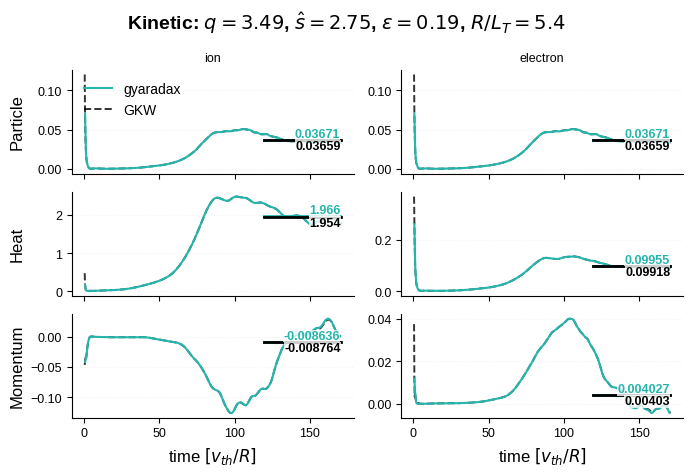

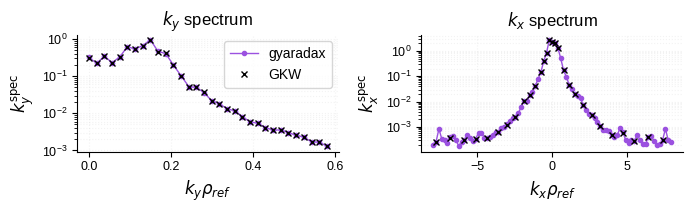

In [6]:
KINETIC_REF_DIR = "/restricteddata/ukaea/gyrokinetics/raw/kinetic_electrons"

for out_dir in kinetic_dirs:
    path = os.path.join("..", out_dir)
    case_name = out_dir.replace("validation_kinetic_", "")

    # resolve ref_dir from the yaml config (folder names don't match 1:1)
    config_path = os.path.join("..", "configs", f"{case_name}.yaml")
    if os.path.exists(config_path):
        cfg = load_config(config_path)
        ref_dir = cfg.run.data_dir
    else:
        ref_dir = os.path.join(KINETIC_REF_DIR, case_name)

    flux_path = os.path.join(path, "fluxes.npz")
    growth_path = os.path.join(path, "growth.npz")

    if not os.path.exists(flux_path) or not os.path.exists(growth_path):
        print(f"skipping {out_dir}: missing .npz files")
        continue

    # fluxes shape: (n_entries, nsp, 3) -> interleave to (6, n_entries)
    # order: [pflux_i, eflux_i, vflux_i, pflux_e, eflux_e, vflux_e]
    fluxes_data = np.load(flux_path)["fluxes"]
    sim_times = np.load(growth_path)["time"]
    sim_fluxes = fluxes_data.reshape(-1, 6).T

    ref_time = np.loadtxt(os.path.join(ref_dir, "time.dat"))[1:]
    ref_fluxes = np.loadtxt(os.path.join(ref_dir, "fluxes.dat"))[1:].T  # (6, n_ref)

    # build title from geometry scalars
    geom = load_geometry(ref_dir)
    q = float(geom["q"])
    shat = float(geom["shat"])
    eps = float(geom["eps"])
    rlt = float(np.asarray(geom["rlt"]).flat[0])
    title = (
        rf"Kinetic: $q={q:.2f}$, $\hat{{s}}={shat:.2f}$, "
        rf"$\varepsilon={eps:.2f}$, $R/L_T={rlt:.1f}$"
    )

    # all 3 fluxes, split by species (ion | electron columns)
    fig = plot_flux_trace(
        sim_times,
        sim_fluxes,
        ref_time=ref_time,
        ref_fluxes=ref_fluxes,
        labels=["Particle", "Heat", "Momentum"],
        title=title,
        n_species=2,
        show_average=True
    )
    fig.savefig(f"figs/kinetic_fluxes_{case_name}.pdf")
    plt.show()

    # spectra if available
    kx_spec_path = os.path.join(path, "kxspec.npz")
    ky_spec_path = os.path.join(path, "kyspec.npz")
    if os.path.exists(kx_spec_path) and os.path.exists(ky_spec_path):
        kx = np.asarray(geom["kxrh"])
        ky = np.asarray(geom["krho"])

        avg_count = min(80, len(np.load(kx_spec_path)["kx_spec"]))
        kx_spec_avg = np.mean(np.load(kx_spec_path)["kx_spec"][-avg_count:], axis=0)
        ky_spec_avg = np.mean(np.load(ky_spec_path)["ky_spec"][-avg_count:], axis=0)

        ref_kx_spec, ref_ky_spec = None, None
        ref_kx_path = os.path.join(ref_dir, "kxspec")
        ref_ky_path = os.path.join(ref_dir, "kyspec")
        if os.path.exists(ref_kx_path) and os.path.exists(ref_ky_path):
            ref_kx_spec = np.mean(np.loadtxt(ref_kx_path)[-avg_count * 3 :], axis=0)
            ref_ky_spec = np.mean(np.loadtxt(ref_ky_path)[-avg_count * 3 :], axis=0)

        fig_spec = plot_spectra(
            kx=kx,
            ky=ky,
            kx_spec=kx_spec_avg,
            ky_spec=ky_spec_avg,
            ref_kx_spec=ref_kx_spec,
            ref_ky_spec=ref_ky_spec,
        )
        fig_spec.savefig(f"figs/kinetic_spectra_{case_name}.pdf")